In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
dataset = pd.read_csv("train.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset.head()

,Year,Decimal Day,Hour,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995,1,0,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995,1,1,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995,1,2,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995,1,3,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995,1,4,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [12]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Year         210384 non-null  int64  
 1   Decimal Day  210384 non-null  int64  
 2   Hour         210384 non-null  int64  
 3   Bz_GSM       210384 non-null  float64
 4   By_GSM       210384 non-null  float64
 5   Bx_GSE       210384 non-null  float64
 6   Kp           210384 non-null  int64  
 7   f10.7        210384 non-null  float64
 8   AL           210384 non-null  int64  
 9   AU           210384 non-null  int64  
 10  T_proton     210384 non-null  float64
 11  Np_density   210384 non-null  float64
 12  V_plasma     210384 non-null  float64
 13  V_Long_GSE   210384 non-null  float64
 14  V_Lat_GSE    210384 non-null  float64
 15  Dst          210384 non-null  int64  
 16  AE           210384 non-null  int64  
dtypes: float64(9), int64(8)
memory usage: 27.3 MB


In [7]:
dataset.describe()

,Year,Decimal Day,Hour,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,2.103840e+05,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,2006.499658,183.125257,11.500000,1.979221,2.080122,1.874579,18.441963,109.263963,-112.295911,68.111116,3.165466e+05,30.821627,457.463357,2.709679,2.247959,-13.242243,180.439758
std,6.922154,105.438893,6.922203,45.103057,45.158247,43.750043,13.617466,51.154913,143.558231,68.055577,1.467536e+06,154.353747,520.345100,53.485555,54.595549,20.120794,197.759337
min,1995.000000,1.000000,0.000000,-57.800000,-43.100000,-40.800000,0.000000,64.600000,-2452.000000,-260.000000,3.299000e+03,0.100000,228.000000,-26.900000,-17.800000,-422.000000,3.000000
25%,2000.000000,92.000000,5.750000,-1.500000,-2.400000,-2.600000,7.000000,74.200000,-153.000000,22.000000,3.719675e+04,3.100000,354.000000,-1.700000,-2.100000,-21.000000,47.000000
50%,2006.500000,183.000000,11.500000,0.000000,0.000000,-0.100000,17.000000,94.100000,-52.000000,44.000000,7.052950e+04,4.900000,407.000000,-0.200000,-0.700000,-10.000000,100.000000
75%,2012.000000,274.000000,17.250000,1.400000,2.500000,2.500000,27.000000,133.100000,-21.000000,92.000000,1.307762e+05,8.100000,486.000000,1.300000,0.700000,-1.000000,245.000000
max,2018.000000,366.000000,23.000000,999.900000,999.900000,999.900000,90.000000,999.900000,22.000000,1226.000000,9.999999e+06,999.900000,9999.000000,999.900000,999.900000,77.000000,2241.000000


In [11]:
len(dataset["Year"].unique())

24

In [13]:
dataset.isna().sum()

Year           0
Decimal Day    0
Hour           0
Bz_GSM         0
By_GSM         0
Bx_GSE         0
Kp             0
f10.7          0
AL             0
AU             0
T_proton       0
Np_density     0
V_plasma       0
V_Long_GSE     0
V_Lat_GSE      0
Dst            0
AE             0
dtype: int64

In [14]:
dataset[["Year", "Decimal Day", "Hour"]].describe()

,Year,Decimal Day,Hour
count,210384.000000,210384.000000,210384.000000
mean,2006.499658,183.125257,11.500000
std,6.922154,105.438893,6.922203
min,1995.000000,1.000000,0.000000
25%,2000.000000,92.000000,5.750000
50%,2006.500000,183.000000,11.500000
75%,2012.000000,274.000000,17.250000
max,2018.000000,366.000000,23.000000


In [18]:
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' + 
    dataset['Decimal Day'].astype(str) + 
    ' ' + 
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)

In [ ]:
dataset["datetime"].describe()

count                 210384
mean     2006-12-31 23:30:00
min      1995-01-01 00:00:00
25%      2000-12-31 11:45:00
50%      2006-12-31 23:30:00
75%      2012-12-31 11:15:00
max      2018-12-31 23:00:00
Name: datetime, dtype: object

In [26]:
dataset.head()

,Year,Decimal Day,Hour,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE,datetime
0,1995,1,0,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32,1995-01-01 00:00:00
1,1995,1,1,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38,1995-01-01 01:00:00
2,1995,1,2,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34,1995-01-01 02:00:00
3,1995,1,3,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36,1995-01-01 03:00:00
4,1995,1,4,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31,1995-01-01 04:00:00


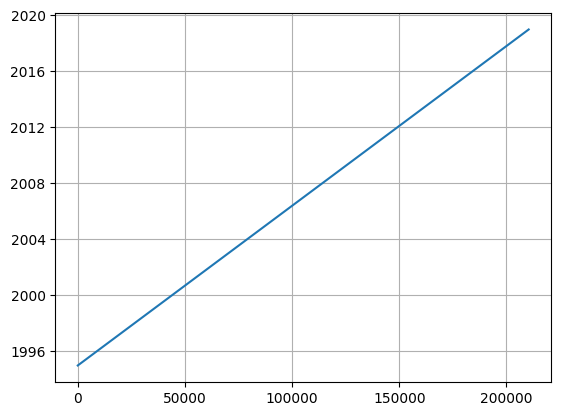

In [32]:
plt.plot(dataset["datetime"])
plt.grid();

### IMF - Interplanetary Magnetic Field (межпланетное магнитное поле)

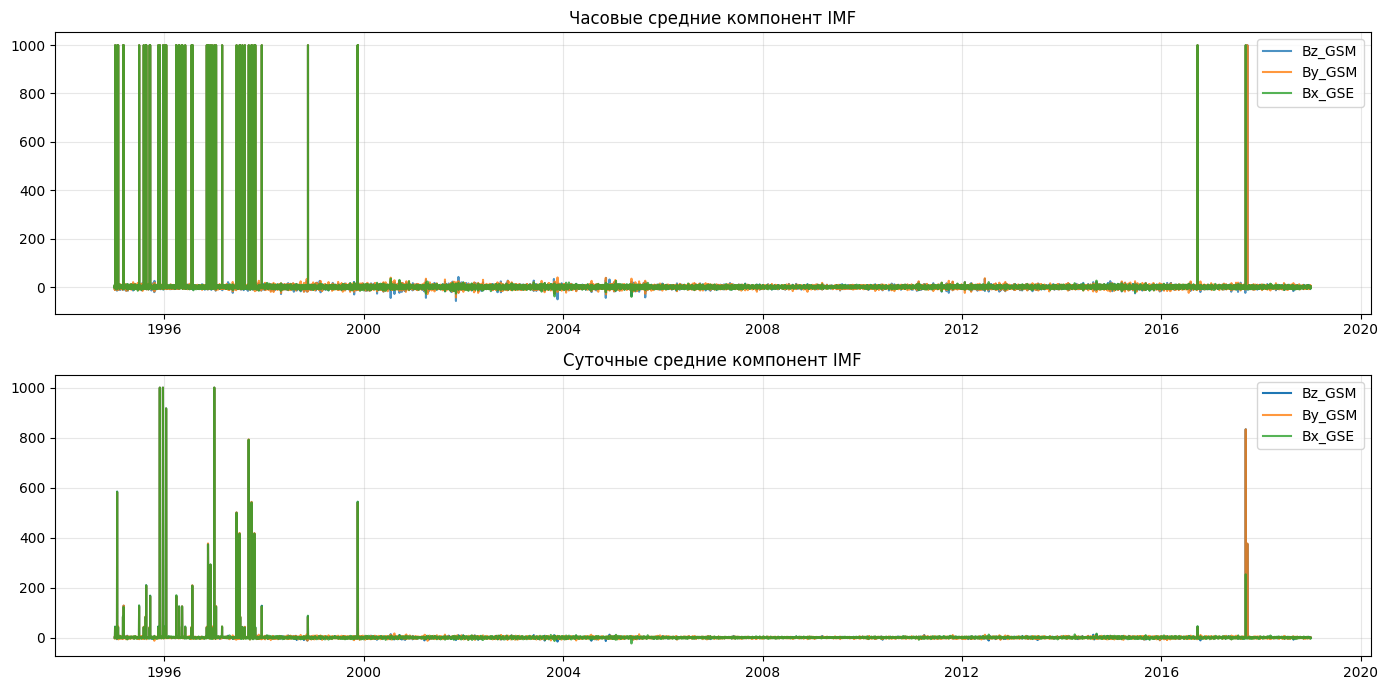

In [66]:
_, axis = plt.subplots(2, 1, figsize=(14, 7))

axis[0].set_title("Часовые средние компонент IMF")
axis[0].plot(dataset["datetime"], dataset["Bz_GSM"], alpha=0.8, label="Bz_GSM")
axis[0].plot(dataset["datetime"], dataset["By_GSM"], alpha=0.8, label="By_GSM")
axis[0].plot(dataset["datetime"], dataset["Bx_GSE"], alpha=0.8, label="Bx_GSE")
axis[0].grid(alpha=0.3)
axis[0].legend()

daily_data = dataset.set_index('datetime').resample('D').mean()
axis[1].set_title("Суточные средние компонент IMF")
axis[1].plot(daily_data.index, daily_data["Bz_GSM"], label="Bz_GSM")
axis[1].plot(daily_data.index, daily_data["By_GSM"], label="By_GSM", alpha=0.8)
axis[1].plot(daily_data.index, daily_data["Bx_GSE"], label="Bx_GSE", alpha=0.8)
axis[1].grid(alpha=0.3)
axis[1].legend()

plt.tight_layout()
plt.show()

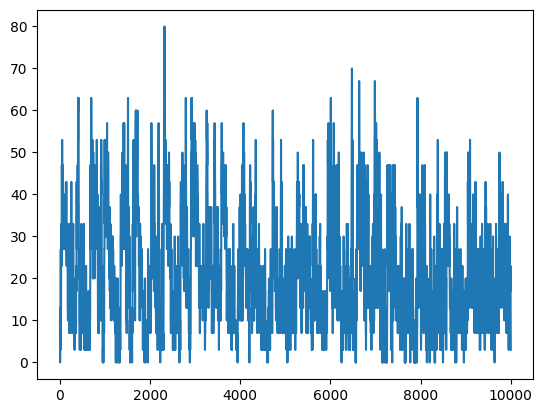

In [71]:
plt.plot(dataset["Kp"][:10000])